
ORIGINAL DATASET:

   RollNo   Name Gender  Maths  Science  English Attendance
0       1   Asha      F     85       78     88.0         92
1       2  Rahul      M     90       85      NaN         85
2       3  Priya      F     78       72     70.0         88
3       4  Arjun      M    120       88     92.0         95
4       5  Kavya      F     65       60     58.0       None
5       6  Rohan      M     55       48     52.0         80
6       7   Neha      F     95       98    100.0         97
7       8   Amit      M     40       42     38.0         70
8       9  Sneha      F     88       85     90.0        abc
9      10  Varun      M     72       75     70.0         85


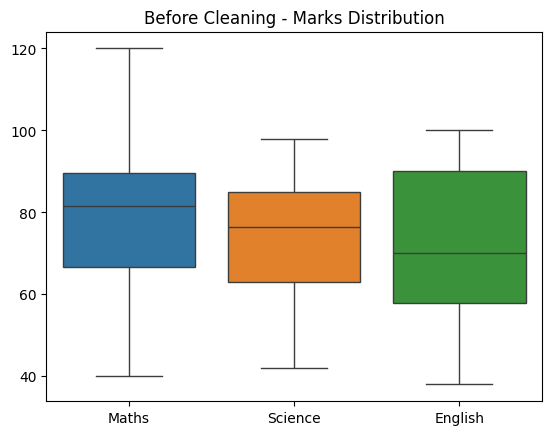


MISSING VALUES BEFORE:

RollNo        0
Name          0
Gender        0
Maths         0
Science       0
English       1
Attendance    1
dtype: int64

AFTER MISSING VALUE HANDLING:

   RollNo   Name Gender  Maths  Science     English  Attendance
0       1   Asha      F     85       78   88.000000        92.0
1       2  Rahul      M     90       85   73.111111        85.0
2       3  Priya      F     78       72   70.000000        88.0
3       4  Arjun      M    120       88   92.000000        95.0
4       5  Kavya      F     65       60   58.000000        86.5
5       6  Rohan      M     55       48   52.000000        80.0
6       7   Neha      F     95       98  100.000000        97.0
7       8   Amit      M     40       42   38.000000        70.0
8       9  Sneha      F     88       85   90.000000        86.5
9      10  Varun      M     72       75   70.000000        85.0


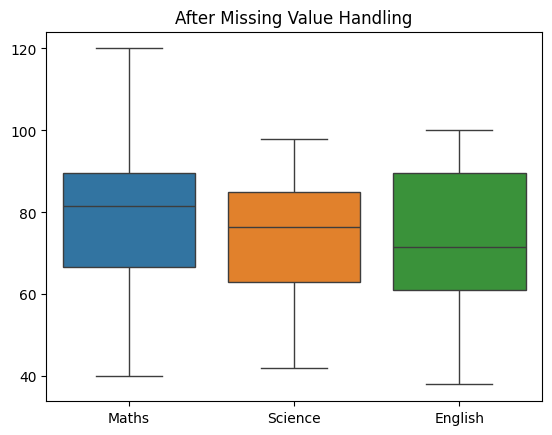


AFTER OUTLIER HANDLING:

   RollNo   Name Gender  Maths  Science     English  Attendance
0       1   Asha      F     85       78   88.000000        92.0
1       2  Rahul      M     90       85   73.111111        85.0
2       3  Priya      F     78       72   70.000000        88.0
3       4  Arjun      M    120       88   92.000000        95.0
4       5  Kavya      F     65       60   58.000000        86.5
5       6  Rohan      M     55       48   52.000000        80.0
6       7   Neha      F     95       98  100.000000        97.0
7       8   Amit      M     40       42   38.000000        76.0
8       9  Sneha      F     88       85   90.000000        86.5
9      10  Varun      M     72       75   70.000000        85.0


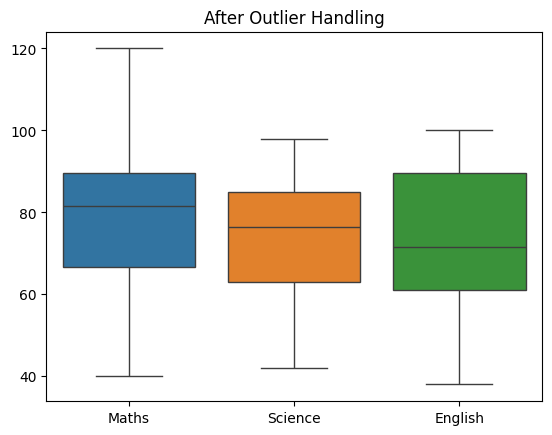


FINAL DATASET WITH NORMALIZATION:

   RollNo   Name Gender  Maths  Science     English  Attendance  \
0       1   Asha      F     85       78   88.000000        92.0   
1       2  Rahul      M     90       85   73.111111        85.0   
2       3  Priya      F     78       72   70.000000        88.0   
3       4  Arjun      M    120       88   92.000000        95.0   
4       5  Kavya      F     65       60   58.000000        86.5   
5       6  Rohan      M     55       48   52.000000        80.0   
6       7   Neha      F     95       98  100.000000        97.0   
7       8   Amit      M     40       42   38.000000        76.0   
8       9  Sneha      F     88       85   90.000000        86.5   
9      10  Varun      M     72       75   70.000000        85.0   

   Maths_Normalized  
0            0.5625  
1            0.6250  
2            0.4750  
3            1.0000  
4            0.3125  
5            0.1875  
6            0.6875  
7            0.0000  
8            0.6000  
9     

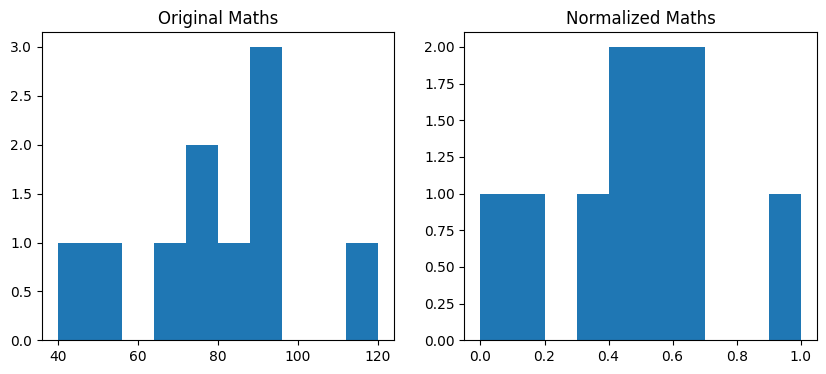

In [2]:
# =========================================================
# DATA WRANGLING II - FINAL (WITH OUTPUT + PLOTS)
# =========================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# 1. ORIGINAL DATASET
# =========================================================

data = {
    "RollNo": [1,2,3,4,5,6,7,8,9,10],
    "Name": ["Asha","Rahul","Priya","Arjun","Kavya","Rohan","Neha","Amit","Sneha","Varun"],
    "Gender": ["F","M","F","M","F","M","F","M","F","M"],
    "Maths": [85,90,78,120,65,55,95,40,88,72],
    "Science": [78,85,72,88,60,48,98,42,85,75],
    "English": [88,np.nan,70,92,58,52,100,38,90,70],
    "Attendance": [92,85,88,95,None,80,97,70,"abc",85]
}

df = pd.DataFrame(data)

print("\nORIGINAL DATASET:\n")
print(df)

# Plot before cleaning
plt.figure()
sns.boxplot(data=df[["Maths","Science","English"]])
plt.title("Before Cleaning - Marks Distribution")
plt.show()

# =========================================================
# 2. MISSING VALUES
# =========================================================

print("\nMISSING VALUES BEFORE:\n")
print(df.isnull().sum())

# Convert Attendance to numeric (handle 'abc')
df["Attendance"] = pd.to_numeric(df["Attendance"], errors='coerce')

# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

print("\nAFTER MISSING VALUE HANDLING:\n")
print(df)

# Plot after missing handling
plt.figure()
sns.boxplot(data=df[["Maths","Science","English"]])
plt.title("After Missing Value Handling")
plt.show()

# =========================================================
# 3. OUTLIER HANDLING (IQR)
# =========================================================

def handle_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.clip(df[col], lower, upper)

for col in ["Maths","Science","English","Attendance"]:
    handle_outliers(col)

print("\nAFTER OUTLIER HANDLING:\n")
print(df)

# Plot after outlier handling
plt.figure()
sns.boxplot(data=df[["Maths","Science","English"]])
plt.title("After Outlier Handling")
plt.show()

# =========================================================
# 4. NORMALIZATION (MIN-MAX)
# =========================================================

df["Maths_Normalized"] = (
    (df["Maths"] - df["Maths"].min()) /
    (df["Maths"].max() - df["Maths"].min())
)

print("\nFINAL DATASET WITH NORMALIZATION:\n")
print(df)

# =========================================================
# 5. HISTOGRAM (TRANSFORMATION EFFECT)
# =========================================================

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df["Maths"])
plt.title("Original Maths")

plt.subplot(1,2,2)
plt.hist(df["Maths_Normalized"])
plt.title("Normalized Maths")

plt.show()